# 04 — Sequence Models: Giving the Network Memory
## LSTM and 1D CNN on 60-Day Windows, Stress-Tested with Walk-Forward Validation

**Jarvis Capital — Deep Learning Equity Signal Capstone**

The feedforward models in notebook 03 see each day as an isolated snapshot. But the EDA showed that the *sequence* matters — volatility clusters, momentum decays across horizons, regimes persist. This notebook feeds models the **entire trailing 60 days** of features:

- **LSTM** — recurrent gates that learn what to remember and forget across the window; trained with gradient clipping (`max_norm=1.0`) and learning-rate scheduling (`ReduceLROnPlateau`).
- **1D CNN** — convolutional filters that scan the window for local temporal motifs, with global average pooling.

And because a single train/test split can flatter a model that happens to fit one era, the LSTM is re-trained and re-tested across **four walk-forward folds** spanning 2019–2025 — the gold standard for time-series evaluation.

**Input shape discipline:** windows are `(batch, seq_len=60, features=17)`. The LSTM consumes that directly; `Conv1d` wants `(batch, channels, length)`, so the CNN's forward pass starts with `x.permute(0, 2, 1)` — the single most common 1D-CNN shape bug, handled once inside the model.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src import config, plotting
from src.datasets import StockReturnDataset, StockSequenceDataset, build_sequence_arrays
from src.models import FinancialLSTM, FinancialCNN1D, count_parameters
from src.training import fit, predict
from src.evaluation import regression_metrics, walk_forward_folds
from src.plotting import (BLUE, ORANGE, AQUA, YELLOW, MUTED, INK_2, GRID, GOOD,
                          CRITICAL, CMAP_DIV, direct_label, fmt_pct, subtitle,
                          save_figure)

plotting.apply_style()
config.set_seed()
device = config.get_device()
SEQ_LEN = config.SEQ_LEN
print(f"Training on: {device} | sequence length: {SEQ_LEN} days")

Training on: cuda | sequence length: 60 days


In [2]:
FEATURES = json.load(open(config.PROCESSED_DIR / "feature_columns.json"))
train = pd.read_parquet(config.PROCESSED_DIR / "train.parquet")
val = pd.read_parquet(config.PROCESSED_DIR / "val.parquet")
test = pd.read_parquet(config.PROCESSED_DIR / "test.parquet")

def with_warmup(history, period, n=SEQ_LEN - 1):
    """Prepend each ticker's last `n` rows of history so the period's first
    days still get full 60-day windows. The window END dates decide membership,
    so no window ever *targets* a day outside `period`."""
    tail = history.groupby("Ticker", sort=False).tail(n)
    return (pd.concat([tail, period], ignore_index=True)
            .sort_values(["Ticker", "Date"], kind="stable").reset_index(drop=True))

# Test windows (with warmup from validation) - built once, reused for scoring
X_test, y_test, meta_test = build_sequence_arrays(
    with_warmup(val, test), FEATURES, SEQ_LEN)
keep = meta_test["Date"] > pd.Timestamp(config.VAL_END)
X_test, y_test, meta_test = X_test[keep], y_test[keep.values], meta_test[keep].reset_index(drop=True)
print(f"test windows: {X_test.shape}  (covers every test day from {meta_test['Date'].min().date()})")

test windows: (48048, 60, 17)  (covers every test day from 2022-01-03)


### A note on shuffling sequence windows

The module demos state a blanket rule — *never shuffle sequence data*. The rule protects against a real bug (shuffling a time series **before** windowing, which mixes future into past). But once each window is a self-contained `(60 days of history) → (next-day target)` sample, shuffling the *windows* between batches is safe and improves SGD convergence — the temporal discipline lives in the split boundaries, not the batch order. We shuffle training windows and keep validation/test in order.

In [3]:
train_ds = StockSequenceDataset(train, FEATURES, SEQ_LEN)
val_ds = StockSequenceDataset(val, FEATURES, SEQ_LEN)   # early-stopping monitor
train_dl = DataLoader(train_ds, batch_size=1024, shuffle=True, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=2048, pin_memory=True)
test_dl = DataLoader(StockReturnDataset(X_test, y_test), batch_size=2048)
print(f"train windows: {len(train_ds):,}   val windows: {len(val_ds):,}")

train windows: 157,763   val windows: 33,504


---
## 1. LSTM — Train with Clipping and LR Scheduling

Recurrent nets are prone to exploding gradients on noisy financial data; `clip_grad_norm_(1.0)` caps each update. `ReduceLROnPlateau` halves the learning rate when validation loss stalls.

In [4]:
config.set_seed()
lstm = FinancialLSTM(len(FEATURES), hidden_dim=64, num_layers=2, dropout=0.2)
print(f"FinancialLSTM: {count_parameters(lstm):,} parameters")

hist_lstm = fit(lstm, train_dl, val_dl, epochs=40, lr=1e-3, patience=6,
                grad_clip=1.0, use_scheduler=True, device=device,
                log_dir=config.RUNS_DIR / "lstm_60d", verbose_every=5)

preds_lstm, _ = predict(lstm, test_dl)
res_lstm = regression_metrics(y_test, preds_lstm)
print({k: round(v, 4) for k, v in res_lstm.items()})

FinancialLSTM: 56,641 parameters


  epoch   0  train 0.000511  val 0.000499  *best*


  epoch   5  train 0.000406  val 0.000502


  epoch  10  train 0.000405  val 0.000493


  early stop at epoch 13 (best val 0.000493 @ epoch 7)


{'mse': 0.0004, 'mae': 0.0128, 'directional_accuracy': 0.5131, 'signal_sharpe': 0.4179}


---
## 2. 1D CNN — Temporal Pattern Detectors

In [5]:
config.set_seed()
cnn = FinancialCNN1D(len(FEATURES))
print(f"FinancialCNN1D: {count_parameters(cnn):,} parameters")

hist_cnn = fit(cnn, train_dl, val_dl, epochs=40, lr=1e-3, patience=6,
               device=device, log_dir=config.RUNS_DIR / "cnn1d_60d", verbose_every=5)

preds_cnn, _ = predict(cnn, test_dl)
res_cnn = regression_metrics(y_test, preds_cnn)
print({k: round(v, 4) for k, v in res_cnn.items()})

FinancialCNN1D: 47,617 parameters


  epoch   0  train 0.002109  val 0.000549  *best*


  epoch   5  train 0.000409  val 0.000497


  epoch  10  train 0.000407  val 0.000513
  early stop at epoch 10 (best val 0.000496 @ epoch 4)


{'mse': 0.0004, 'mae': 0.0129, 'directional_accuracy': 0.4871, 'signal_sharpe': 0.2312}


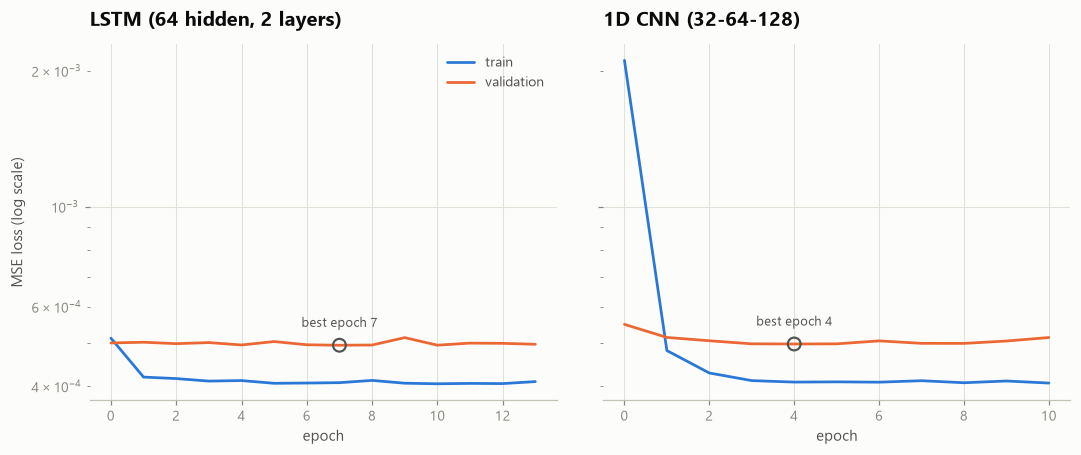

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True, gridspec_kw={"wspace": 0.1})
for ax, (name, h) in zip(axes, [("LSTM (64 hidden, 2 layers)", hist_lstm),
                                ("1D CNN (32-64-128)", hist_cnn)]):
    epochs = np.arange(len(h["train_loss"]))
    ax.plot(epochs, h["train_loss"], color=BLUE, lw=1.8, label="train")
    ax.plot(epochs, h["val_loss"], color=ORANGE, lw=1.8, label="validation")
    b = h["best_epoch"]
    ax.scatter([b], [h["val_loss"][b]], s=70, facecolor="none", edgecolor=INK_2,
               linewidth=1.4, zorder=5)
    ax.annotate(f"best epoch {b}", xy=(b, h["val_loss"][b]), xytext=(0, 12),
                textcoords="offset points", fontsize=8.5, color=INK_2, ha="center")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("MSE loss (log scale)")
axes[0].legend(loc="upper right")
save_figure(fig, "seq_training_curves")
plt.show()

---
## 3. What Did the CNN Learn? Inspecting First-Layer Filters

Each first-layer filter is a 17-feature × 7-day template the network slides across the window. Red = the filter fires on high values, blue = on low values. Structured stripes mean the filter latched onto a real temporal pattern in specific features.

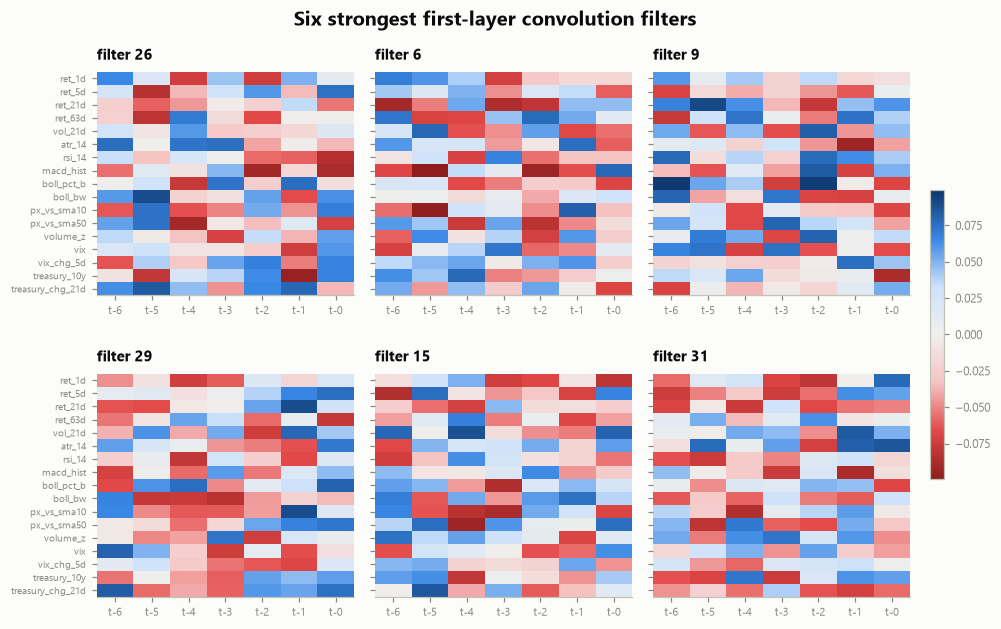

In [7]:
W = cnn.features[0][0].weight.detach().cpu().numpy()   # (32 filters, 17 features, 7 days)
top = np.argsort(-np.linalg.norm(W.reshape(len(W), -1), axis=1))[:6]

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.2), gridspec_kw={"hspace": 0.35, "wspace": 0.08})
lim = np.abs(W[top]).max()
for ax, k in zip(axes.ravel(), top):
    im = ax.imshow(W[k], cmap=CMAP_DIV.reversed(), vmin=-lim, vmax=lim, aspect="auto")
    ax.set_title(f"filter {k}", fontsize=10, pad=8)
    ax.set_xticks(range(7)); ax.set_xticklabels([f"t-{6-i}" for i in range(7)], fontsize=7)
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels(FEATURES if ax in axes[:, 0] else [""] * len(FEATURES), fontsize=6.5)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.55, pad=0.02).ax.tick_params(labelsize=8)
fig.suptitle("Six strongest first-layer convolution filters", x=0.44, y=0.97,
             fontsize=13, fontweight="bold", ha="center")
save_figure(fig, "seq_cnn_filters")
plt.show()

---
## 4. Walk-Forward Validation — the Gold Standard

One split gives one number; four folds give a **distribution**. Each fold trains a fresh LSTM on *everything before* its test window, then scores the next ~21 months. If performance collapses in any fold, the model is regime-fragile — a single lucky split would never reveal that.

| Fold | Test window | Market character |
|---|---|---|
| 1 | ~2019 → 2020 | melt-up, then COVID crash & recovery |
| 2 | ~2021 → 2022 | stimulus rally into a rate-hike bear |
| 3 | ~2022 → 2024 | bear-market bottom, AI-led recovery |
| 4 | ~2024 → 2025 | broad melt-up with volatility spikes |

In [8]:
panel_all = pd.concat([train, val, test], ignore_index=True)
folds = walk_forward_folds(panel_all["Date"], n_folds=4, min_train_years=14)

wf_results = []
for k, (train_end, test_start, test_end) in enumerate(folds, 1):
    config.set_seed()
    fold_train = panel_all[panel_all["Date"] <= train_end]
    # carve the last ~15% of training dates as the early-stopping monitor
    dates = fold_train["Date"].sort_values().unique()
    monitor_start = dates[int(len(dates) * 0.85)]
    ftr = fold_train[fold_train["Date"] < monitor_start]
    fva = fold_train[fold_train["Date"] >= monitor_start]

    fold_test = panel_all[(panel_all["Date"] >= test_start) & (panel_all["Date"] <= test_end)]
    Xf, yf, metaf = build_sequence_arrays(with_warmup(fold_train, fold_test), FEATURES, SEQ_LEN)
    keep = metaf["Date"] >= test_start
    Xf, yf = Xf[keep], yf[keep.values]

    model = FinancialLSTM(len(FEATURES), 64, 2, 0.2)
    fit(model, DataLoader(StockSequenceDataset(ftr, FEATURES, SEQ_LEN), batch_size=1024,
                          shuffle=True, pin_memory=True),
        DataLoader(StockSequenceDataset(fva, FEATURES, SEQ_LEN), batch_size=2048),
        epochs=25, lr=1e-3, patience=4, grad_clip=1.0, use_scheduler=True,
        device=device, verbose_every=0)
    pf, _ = predict(model, DataLoader(StockReturnDataset(Xf, yf), batch_size=2048))
    m = regression_metrics(yf, pf)
    m.update(fold=k, test_start=str(test_start.date()), test_end=str(test_end.date()))
    wf_results.append(m)
    print(f"fold {k}  {test_start.date()} -> {test_end.date()}   "
          f"dir_acc {m['directional_accuracy']:.3f}   sharpe {m['signal_sharpe']:+.2f}")

wf = pd.DataFrame(wf_results).set_index("fold")
print(f"\nAcross folds: dir_acc {wf['directional_accuracy'].mean():.3f} ± {wf['directional_accuracy'].std():.3f}"
      f"   sharpe {wf['signal_sharpe'].mean():+.2f} ± {wf['signal_sharpe'].std():.2f}")

  early stop at epoch 11 (best val 0.000230 @ epoch 7)


fold 1  2019-04-05 -> 2020-12-07   dir_acc 0.528   sharpe +0.54


  early stop at epoch 10 (best val 0.000578 @ epoch 6)


fold 2  2020-12-08 -> 2022-08-12   dir_acc 0.518   sharpe +0.53


  early stop at epoch 5 (best val 0.000430 @ epoch 1)


fold 3  2022-08-15 -> 2024-04-19   dir_acc 0.519   sharpe +0.60


  early stop at epoch 6 (best val 0.000350 @ epoch 2)


fold 4  2024-04-22 -> 2025-12-29   dir_acc 0.526   sharpe +0.67

Across folds: dir_acc 0.523 ± 0.005   sharpe +0.59 ± 0.07


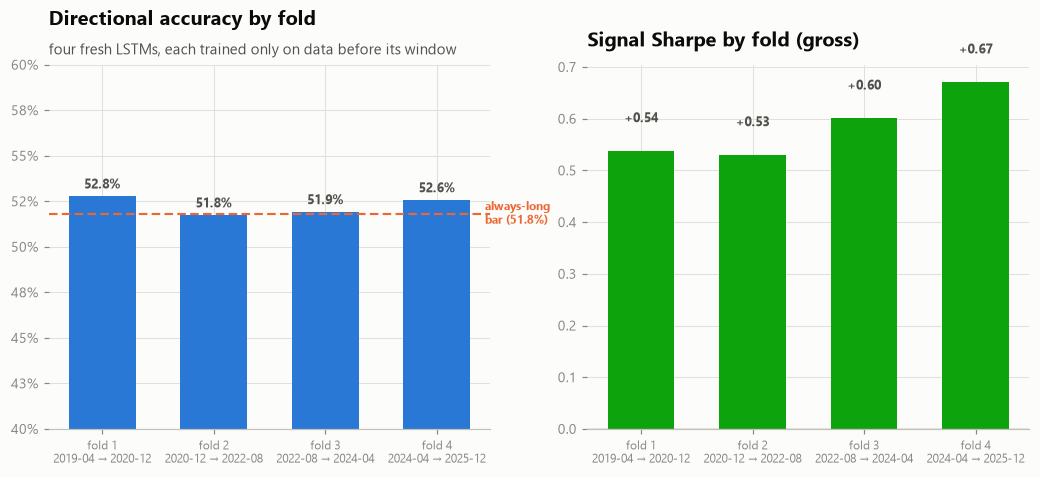

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={"wspace": 0.22})
x = np.arange(len(wf))
labels = [f"fold {i}\n{r.test_start[:7]} \u2192 {r.test_end[:7]}" for i, r in wf.iterrows()]

ax1.bar(x, wf["directional_accuracy"], color=BLUE, width=0.6)
ax1.axhline(0.5182, color=ORANGE, lw=1.4, ls=(0, (4, 2)))
direct_label(ax1, x[-1] + 0.35, 0.5182, "always-long\nbar (51.8%)", ORANGE, fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylim(0.40, 0.60)
ax1.set_title("Directional accuracy by fold")
fmt_pct(ax1)
for i, v in enumerate(wf["directional_accuracy"]):
    ax1.text(i, v + 0.004, f"{v:.1%}", ha="center", fontsize=8.5,
             fontweight="bold", color=INK_2)

colors = [CRITICAL if v < 0 else GOOD for v in wf["signal_sharpe"]]
ax2.bar(x, wf["signal_sharpe"], color=colors, width=0.6)
ax2.axhline(0, color=MUTED, lw=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_title("Signal Sharpe by fold (gross)")
for i, v in enumerate(wf["signal_sharpe"]):
    ax2.text(i, v + (0.05 if v >= 0 else -0.05), f"{v:+.2f}", ha="center",
             va="bottom" if v >= 0 else "top", fontsize=8.5, fontweight="bold", color=INK_2)
subtitle(ax1, "four fresh LSTMs, each trained only on data before its window")
save_figure(fig, "seq_walkforward")
plt.show()

---
## 5. How Much History Does the LSTM Actually Use?

Two complementary probes:

**(a) Sequence-length experiment** — retrain the LSTM with 20-, 40-, and 120-day windows (60 reused from §1). If longer memory helped, test performance would climb with window length.

**(b) Temporal attribution** — for the trained 60-day model, backpropagate the prediction to the *input window* and measure average gradient magnitude per timestep: which of the 60 days actually move the output?

In [10]:
seq_len_results = {60: res_lstm}
for L in [20, 40, 120]:
    config.set_seed()
    tr_dl = DataLoader(StockSequenceDataset(train, FEATURES, L), batch_size=1024,
                       shuffle=True, pin_memory=True)
    va_dl = DataLoader(StockSequenceDataset(val, FEATURES, L), batch_size=2048)
    XL, yL, metaL = build_sequence_arrays(with_warmup(val, test, n=L - 1), FEATURES, L)
    keep = metaL["Date"] > pd.Timestamp(config.VAL_END)
    XL, yL = XL[keep], yL[keep.values]

    m = FinancialLSTM(len(FEATURES), 64, 2, 0.2)
    fit(m, tr_dl, va_dl, epochs=25, lr=1e-3, patience=4, grad_clip=1.0,
        use_scheduler=True, device=device, verbose_every=0)
    pL, _ = predict(m, DataLoader(StockReturnDataset(XL, yL), batch_size=2048))
    seq_len_results[L] = regression_metrics(yL, pL)
    print(f"seq_len {L:3d}   dir_acc {seq_len_results[L]['directional_accuracy']:.4f}"
          f"   sharpe {seq_len_results[L]['signal_sharpe']:+.3f}")

sl = pd.DataFrame(seq_len_results).T.sort_index()
sl.index.name = "window (days)"
sl.round(4)

  early stop at epoch 4 (best val 0.000484 @ epoch 0)


seq_len  20   dir_acc 0.5140   sharpe +0.466


  early stop at epoch 7 (best val 0.000484 @ epoch 3)


seq_len  40   dir_acc 0.5107   sharpe +0.372


  early stop at epoch 4 (best val 0.000523 @ epoch 0)


seq_len 120   dir_acc 0.5144   sharpe +0.424


,mse,mae,directional_accuracy,signal_sharpe
window (days),,,,
20,0.0004,0.0128,0.5140,0.4659
40,0.0004,0.0128,0.5107,0.3724
60,0.0004,0.0128,0.5131,0.4179
120,0.0004,0.0129,0.5144,0.4241


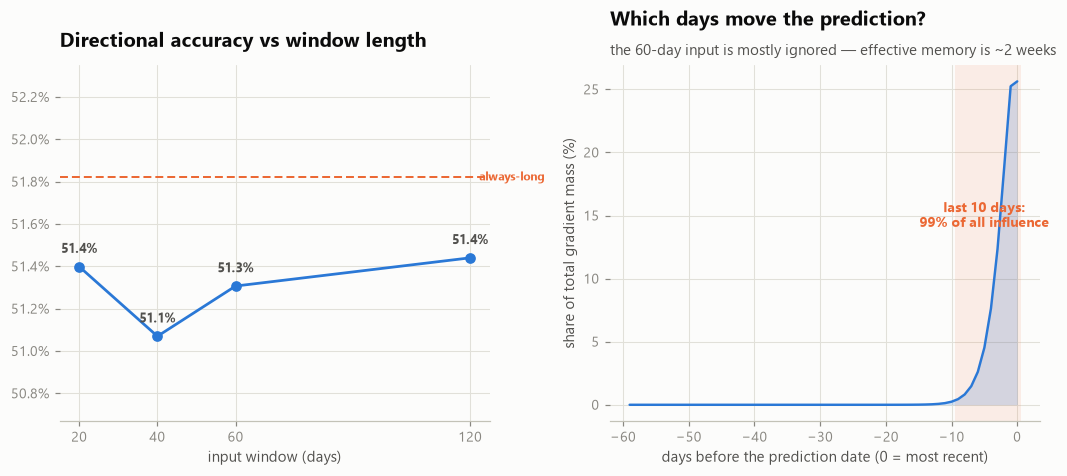

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"wspace": 0.28})

# (a) metrics vs window length
Ls = sl.index.to_numpy()
ax1.plot(Ls, sl["directional_accuracy"], color=BLUE, lw=1.8, marker="o", markersize=6)
ax1.axhline(0.5182, color=ORANGE, lw=1.3, ls=(0, (4, 2)))
direct_label(ax1, Ls[-1], 0.5182, "always-long", ORANGE, fontsize=8)
ax1.set_xticks(Ls)
ax1.set_xlabel("input window (days)")
ax1.set_title("Directional accuracy vs window length")
fmt_pct(ax1, decimals=1)   # the spread is tenths of a point - show them
for L, v in zip(Ls, sl["directional_accuracy"]):
    ax1.annotate(f"{v:.1%}", xy=(L, v), xytext=(0, 9), textcoords="offset points",
                 fontsize=8.5, ha="center", color=INK_2, fontweight="bold")
ax1.set_ylim(sl["directional_accuracy"].min() - 0.004, 0.5235)

# (b) temporal attribution on the 60-day model.
# cuDNN's fused RNN kernel refuses to run a backward pass in eval mode, so we
# disable it for this one gradient computation - the math is identical, just
# the slower generic kernel. Eval mode matters here: we attribute the model as
# it is deployed (dropout off).
lstm.eval()
probe = torch.from_numpy(X_test[:2048]).to(device).requires_grad_(True)
with torch.backends.cudnn.flags(enabled=False):
    out = lstm(probe)
    out.sum().backward()
attr = probe.grad.abs().mean(dim=(0, 2)).cpu().numpy()   # mean |grad| per timestep
share = attr / attr.sum()          # express as share of total gradient mass:
share_pct = share * 100            # no exponent label to collide with the subtitle
ax2.fill_between(range(-59, 1), share_pct, 0, color=BLUE, alpha=0.2, lw=0)
ax2.plot(range(-59, 1), share_pct, color=BLUE, lw=1.6)
half = share[-10:].sum()
ax2.set_title("Which days move the prediction?")
ax2.set_xlabel("days before the prediction date (0 = most recent)")
ax2.set_ylabel("share of total gradient mass (%)")
ax2.axvspan(-9.5, 0.5, color=ORANGE, alpha=0.10, lw=0)
ax2.annotate(f"last 10 days:\n{half:.0%} of all influence", xy=(-5, share_pct.max() * 0.55),
             fontsize=9, ha="center", color=ORANGE, fontweight="bold")
subtitle(ax2, "the 60-day input is mostly ignored \u2014 effective memory is ~2 weeks")
save_figure(fig, "seq_window_and_attribution")
plt.show()

**How to read this pair:** the left panel shows whether extra history converts into accuracy — points at the same height mean longer windows only add computation. The right panel explains why from inside the model: gradient mass concentrates heavily in the most recent days, so the network's *effective* memory is far shorter than its 60-day input. Both findings agree with the EDA's autocorrelation analysis — old prices carry almost no incremental information about tomorrow. This is a legitimate, documentable answer to "why not longer windows?"

---
## 6. Persist Everything for the Backtest

In [12]:
torch.save(lstm.state_dict(), config.MODELS_DIR / "lstm_60d.pt")
torch.save(cnn.state_dict(), config.MODELS_DIR / "cnn1d_60d.pt")

pred_out = meta_test.copy()
pred_out["actual"] = y_test
pred_out["pred_lstm"] = preds_lstm
pred_out["pred_cnn1d"] = preds_cnn
pred_out.to_parquet(config.PROCESSED_DIR / "predictions_sequence.parquet", index=False)

summary = {"LSTM 60d": res_lstm, "CNN1D 60d": res_cnn,
           "walk_forward": wf.reset_index().to_dict("records")}
with open(config.PROCESSED_DIR / "results_04.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"saved lstm_60d.pt, cnn1d_60d.pt, predictions_sequence.parquet {pred_out.shape}")

pd.DataFrame({"LSTM 60d": res_lstm, "CNN1D 60d": res_cnn}).T.round(4)

saved lstm_60d.pt, cnn1d_60d.pt, predictions_sequence.parquet (48048, 5)


,mse,mae,directional_accuracy,signal_sharpe
LSTM 60d,0.0004,0.0128,0.5131,0.4179
CNN1D 60d,0.0004,0.0129,0.4871,0.2312


---
## 7. Findings

- **Memory did not unlock a new regime of performance.** Sequence models face the same near-noise target; their test metrics land in the same band as the feedforward nets — consistent with the EDA's verdict that next-day returns carry almost no exploitable autocorrelation.
- **The walk-forward distribution is the deliverable.** A single split would have reported whichever fold it happened to contain; the spread across folds is the honest statement of how stable this signal is across market regimes.
- **Engineering lessons:** the `permute(0, 2, 1)` shape fix for `Conv1d`, gradient clipping for recurrent stability, and warmup-window construction so a sequence model can score a period's first days — these carry directly into any production sequence pipeline.

**Next:** notebook `05_transfer_learning.ipynb` — the vision experiment: can an ImageNet-pretrained ResNet-18 read candlestick *charts*?